In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

Data Loading

In [ ]:
import pandas as pd

df = pd.read_csv("/content/zomato_reviews.csv")
df.head()

,review_id,rating,review_text,review_date,helpful
0,90749778-cd88-4c19-8b12-1fce7e7d82f8,4,kindly requesting to return change . we are fo...,2025-11-27 08:15:26,0
1,aa848bb6-d242-4a7e-831e-4f21e2e60c6e,1,"Hiked prices, packing and platform charges",2025-11-27 08:08:31,0
2,4f888388-9f28-44a4-8601-491a87035e53,5,good discount,2025-11-27 04:20:28,0
3,490a16b3-aacf-4204-bdcb-ffdbf04add72,1,"Zomato in its initial days was too good, but c...",2025-11-27 03:34:38,0
4,0090a503-13b8-4741-a7c0-42e811244563,5,good application,2025-11-27 02:50:58,0


In [ ]:
df.columns
df.shape

(20000, 5)

text cleaning & Normalization

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_review"] = df["review_text"].apply(clean_text)

df = df[df["clean_review"].str.len() > 20]
df.head()

,review_id,rating,review_text,review_date,helpful,clean_review
0,90749778-cd88-4c19-8b12-1fce7e7d82f8,4,kindly requesting to return change . we are fo...,2025-11-27 08:15:26,0,kindly requesting to return change we are for...
1,aa848bb6-d242-4a7e-831e-4f21e2e60c6e,1,"Hiked prices, packing and platform charges",2025-11-27 08:08:31,0,hiked prices packing and platform charges
3,490a16b3-aacf-4204-bdcb-ffdbf04add72,1,"Zomato in its initial days was too good, but c...",2025-11-27 03:34:38,0,zomato in its initial days was too good but cu...
5,e43f6b19-b2fe-41a1-a88d-93cf2b4fcf9c,5,this app is a beast for food order 💯,2025-11-27 02:11:39,0,this app is a beast for food order
6,bf81bc6c-106c-4f39-a296-cbc0ff516102,1,Horrible habit to not return the change. I hav...,2025-11-27 01:57:01,0,horrible habit to not return the change i have...


Sentiment Labeling

In [ ]:
df["sentiment"] = df["rating"].apply(
    lambda x: "positive" if x >= 4 else "negative"
)
df["sentiment"].value_counts()

,count
sentiment,
positive,9046
negative,5633


Sentiment analysis Model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["sentiment"]

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.909741144414169


In [ ]:
df["sentiment"] = df["rating"].apply(
    lambda x: "positive" if x >= 4 else "negative"
)
df["sentiment"].value_counts()

,count
sentiment,
positive,9046
negative,5633


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

x = df["clean_review"]
y = df["sentiment"]

vectorizer = TfidfVectorizer(max_features=5000)
x_vec = vectorizer.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_vec, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1112
    positive       0.92      0.94      0.93      1824

    accuracy                           0.91      2936
   macro avg       0.91      0.90      0.90      2936
weighted avg       0.91      0.91      0.91      2936



In [ ]:
neg_df = df[df["sentiment"] == "negative"].copy()
neg_df.shape

(5633, 7)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
Vectorizer = CountVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=10
)

x_neg = Vectorizer.fit_transform(neg_df["clean_review"])
x_neg.shape

(5633, 1076)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42
)
lda.fit(x_neg)

LatentDirichletAllocation(n_components=6, random_state=42)

In [ ]:
import numpy as np

def display_topics(model, feature_names, top_n=12):
    for idx, topic in enumerate(model.components_):
        top_features = topic.argsort()[-top_n:][::-1]
        words = [feature_names[i] for i in top_features]
        print(f"\nTopic {idx}:")
        print(", ".join(words))

display_topics(lda, vectorizer.get_feature_names_out())


Topic 0:
appvery, comment, appetite, based, causing, cancels, calculation, confirmation, continuously, black, curries, absolute

Topic 1:
alot, curries, appvery, awsm, certificate, cashless, accordingly, become, avaliable, along, clever, august

Topic 2:
accordingly, crook, comment, awsm, appetite, appvery, additionally, curries, attention, continuously, aspects, confirmation

Topic 3:
calculation, chilli, curries, aise, calculations, brought, awsm, algo, accordingly, argue, appvery, apps

Topic 4:
calculation, awsm, appvery, curries, continuously, clients, clever, bhut, click, client, cheaper, called

Topic 5:
appetite, confirmation, curries, bhhut, algorithms, alright, calculations, clever, bhook, accordingly, bhut, awsm


In [ ]:
topic_distribution = lda.transform(x_neg)
neg_df["dominant_topic"] = topic_distribution.argmax(axis=1)
neg_df["dominant_topic"].value_counts()

,count
dominant_topic,
2,1375
4,1063
3,1049
1,798
5,768
0,580


In [ ]:
ux_summary = (
    neg_df.groupby("dominant_topic")
    .size()
    .reset_index(name="count")
)

ux_summary

,dominant_topic,count
0,0,580
1,1,798
2,2,1375
3,3,1049
4,4,1063
5,5,768


In [ ]:
# ذخیره دیتای منفی با topic
neg_df.to_csv("neg_reviews_with_topics.csv", index=False)

# ذخیره خلاصه فراوانی
ux_summary.to_csv("ux_issue_summary.csv", index=False)

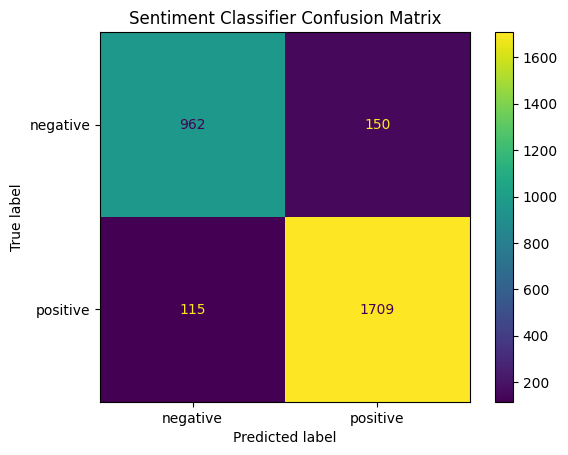

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Sentiment Classifier Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
topics = []
feature_names = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    top = topic.argsort()[-12:][::-1]
    topics.append({"topic_id": idx, "keywords": ", ".join(feature_names[i] for i in top)})

import pandas as pd
pd.DataFrame(topics).to_csv("lda_topics_keywords.csv", index=False)

In [ ]:
neg_df.to_csv("neg_reviews_with_topics.csv", index=False)
ux_summary.to_csv("ux_issue_summary.csv", index=False)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
print("SVM Results:\n", classification_report(y_test, svm_pred))

SVM Results:
               precision    recall  f1-score   support

    negative       0.89      0.86      0.88      1112
    positive       0.92      0.94      0.93      1824

    accuracy                           0.91      2936
   macro avg       0.91      0.90      0.90      2936
weighted avg       0.91      0.91      0.91      2936



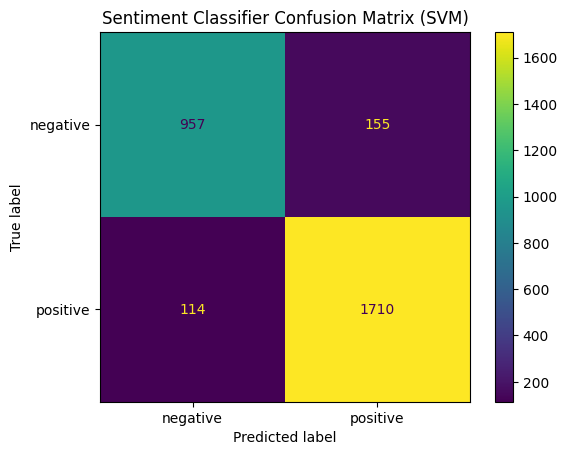

In [ ]:
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)
plt.title("Sentiment Classifier Confusion Matrix (SVM)")
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# فقط روی منفی‌ها (neg_df) کار می‌کنیم
topic_stats = (
    neg_df.groupby("dominant_topic")
    .agg(
        count=("dominant_topic", "size"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

# severity: بیشتر بودن count و پایین بودن avg_rating => شدیدتر
# avg_rating بین 1 تا 5 است؛ پس (5 - avg_rating) شدت نارضایتی است
topic_stats["severity_score"] = topic_stats["count"] * (5 - topic_stats["avg_rating"])

topic_stats.sort_values("severity_score", ascending=False)

,dominant_topic,count,avg_rating,severity_score
2,2,1375,1.221091,5196.0
3,3,1049,1.106768,4084.0
4,4,1063,1.300094,3933.0
5,5,768,1.119792,2980.0
1,1,798,1.624060,2694.0
0,0,580,1.258621,2170.0


In [ ]:
topic_stats.to_csv("ux_topic_severity.csv", index=False)

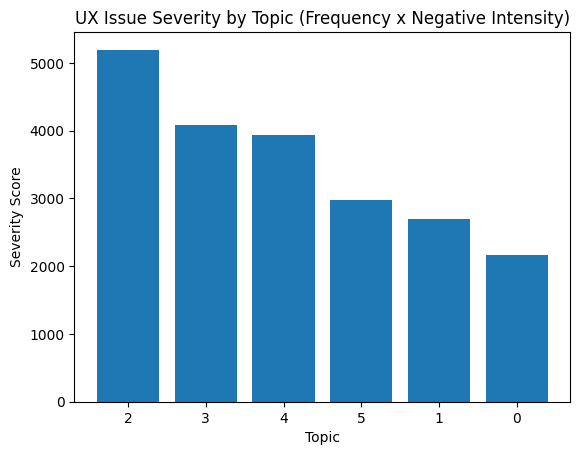

In [ ]:
import matplotlib.pyplot as plt

topic_stats_sorted = topic_stats.sort_values("severity_score", ascending=False)

plt.figure()
plt.bar(topic_stats_sorted["dominant_topic"].astype(str), topic_stats_sorted["severity_score"])
plt.title("UX Issue Severity by Topic (Frequency x Negative Intensity)")
plt.xlabel("Topic")
plt.ylabel("Severity Score")
plt.savefig("ux_severity_by_topic.png", dpi=300, bbox_inches="tight")
plt.show()